# Projeto: Soluções Cognitivas para a Nova Economia Espacial - Agricultura Inteligente
* **Integrantes:** Rodrigo Nery RM-568246, Guilherme Fernandes RM-567389
* **Turma:** 1 TIAPA
* **Disciplina:** Machine Learning & Modelling





# **Importações e Carregamento (Exploração)**

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Valores Ausentes por Coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


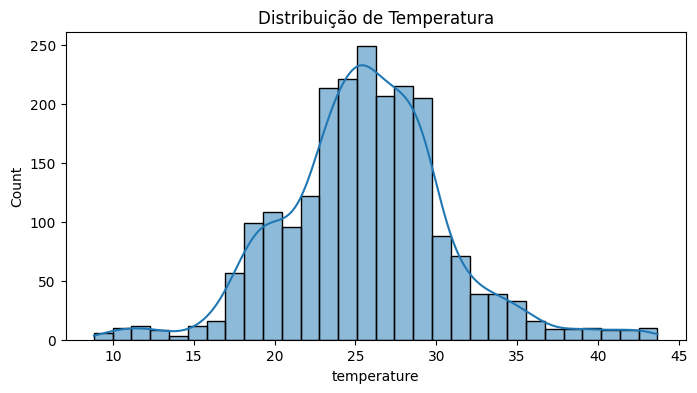

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Carregamento do dataset
# Certifique-se de que o arquivo 'Crop_recommendation.csv' está na mesma pasta
df = pd.read_csv('Crop_recommendation.csv')

# Visualização inicial
display(df.head())

# Estatísticas descritivas
display(df.describe())

# Identificação de valores ausentes
print("Valores Ausentes por Coluna:")
print(df.isnull().sum())

# Análise básica de distribuição (Exemplo: Distribuição de Temperatura)
plt.figure(figsize=(8, 4))
sns.histplot(df['temperature'], kde=True, bins=30)
plt.title("Distribuição de Temperatura")
plt.show()

# **Pré-processamento**

In [ ]:
# Separar features (X) e target (y)
X = df.drop('label', axis=1)
y = df['label']


# Pré-processamento para o KNN (Normalização/Padronização)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['label'] = y

# Pré-processamento para o Apriori (Discretização)
# O Apriori precisa de dados categóricos. Vamos transformar variáveis contínuas em faixas (Baixo, Medio, Alto)
df_apriori = pd.DataFrame()
for col in X.columns:
    df_apriori[col] = pd.qcut(df[col], q=3, labels=['Baixo', 'Medio', 'Alto'])

df_apriori['label'] = y

# Transformar em variáveis dummy (One-Hot Encoding) para o mlxtend
df_apriori_dummies = pd.get_dummies(df_apriori)

# **Sistema de Recomendação com KNN**

In [ ]:
# Treinando o modelo KNN para buscar os 5 vizinhos mais próximos
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(X_scaled)

def recomendar_cultura(nova_amostra_dict):
    """
    Recebe um dicionário com os dados ambientais e retorna as recomendações.
    """
    # Converter para dataframe e padronizar
    amostra_df = pd.DataFrame([nova_amostra_dict])
    amostra_scaled = scaler.transform(amostra_df)

    # Calcular similaridade/proximidade
    distancias, indices = knn.kneighbors(amostra_scaled)

    # Gerar recomendações baseadas nos índices vizinhos
    recomendacoes = df.iloc[indices[0]]['label'].value_counts()

    print("Condições de Entrada:")
    for k, v in nova_amostra_dict.items():
        print(f" - {k}: {v}")

    print("\nCulturas Recomendadas (baseado em similaridade):")
    for cultura, contagem in recomendacoes.items():
        print(f" - {cultura.capitalize()} (Apareceu em {contagem}/5 vizinhos mais próximos)")

# Exemplo de Entrada e Saída
condicoes_teste = {
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 20.8, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9
}

recomendar_cultura(condicoes_teste)

Condições de Entrada:
 - N: 90
 - P: 42
 - K: 43
 - temperature: 20.8
 - humidity: 82.0
 - ph: 6.5
 - rainfall: 202.9

Culturas Recomendadas (baseado em similaridade):
 - Rice (Apareceu em 5/5 vizinhos mais próximos)


# **Regras de Associação com Apriori**

In [ ]:
# Gerar itens frequentes (Reduzimos o suporte mínimo para 2% para capturar mais padrões)
frequent_itemsets = apriori(df_apriori_dummies, min_support=0.02, use_colnames=True)

# Gerar regras de associação (Reduzimos o lift mínimo para 1.5)
regras = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)

# Filtrar regras interessantes: Queremos regras onde o antecedente seja clima/solo e o consequente seja uma cultura (label)
regras_finais = regras[regras['consequents'].apply(lambda x: any('label' in item for item in x))]

# Ordenar pelas regras mais relevantes (maior Lift e Confiança)
regras_finais = regras_finais.sort_values(by=['lift', 'confidence'], ascending=[False, False])

display(regras_finais[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Interpretação com validação para evitar IndexError
print("\nInterpretação da Principal Regra Encontrada:")

if not regras_finais.empty:
    principal_regra = regras_finais.iloc[0]
    ant = list(principal_regra['antecedents'])
    cons = list(principal_regra['consequents'])[0].replace("label_", "")

    print(f"Se o solo/clima apresentar {ant},")
    print(f"Há uma confiança de {principal_regra['confidence']*100:.2f}% de que a cultura adequada é '{cons}'.")
    print(f"O Lift de {principal_regra['lift']:.2f} indica que essa associação é {principal_regra['lift']:.2f} vezes mais forte do que o acaso.")
else:
    print("O modelo não encontrou regras de associação fortes o suficiente relacionando as variáveis ambientais às culturas.")
    print("Tente reduzir ainda mais os parâmetros 'min_support' (ex: 0.01) ou 'min_threshold' na função association_rules.")

,antecedents,consequents,support,confidence,lift
38571,"(K_Medio, rainfall_Medio, temperature_Alto, ph...","(N_Baixo, label_mango)",0.020000,0.733333,23.725490
32702,"(K_Alto, humidity_Baixo, rainfall_Medio, N_Medio)","(ph_Alto, label_chickpea)",0.023182,0.739130,23.566478
32716,"(K_Alto, ph_Alto, humidity_Baixo)","(N_Medio, label_chickpea, rainfall_Medio)",0.023182,0.739130,23.566478
38949,"(K_Alto, temperature_Baixo, rainfall_Medio, hu...","(ph_Alto, label_chickpea)",0.023182,0.739130,23.566478
38969,"(K_Alto, humidity_Baixo, ph_Alto, temperature_...","(N_Medio, label_chickpea, rainfall_Medio)",0.023182,0.739130,23.566478
38980,"(K_Alto, humidity_Baixo, rainfall_Medio, N_Medio)","(temperature_Baixo, ph_Alto, label_chickpea)",0.023182,0.739130,23.566478
39009,"(K_Alto, ph_Alto, humidity_Baixo)","(N_Medio, temperature_Baixo, label_chickpea, r...",0.023182,0.739130,23.566478
32144,"(K_Alto, humidity_Baixo, P_Alto, N_Medio)","(ph_Alto, label_chickpea)",0.020000,0.733333,23.381643
38697,"(K_Alto, temperature_Baixo, P_Alto, humidity_B...","(ph_Alto, label_chickpea)",0.020000,0.733333,23.381643
38728,"(K_Alto, humidity_Baixo, P_Alto, N_Medio)","(temperature_Baixo, ph_Alto, label_chickpea)",0.020000,0.733333,23.381643



Interpretação da Principal Regra Encontrada:
Se o solo/clima apresentar ['K_Medio', 'rainfall_Medio', 'temperature_Alto', 'ph_Baixo', 'humidity_Baixo'],
Há uma confiança de 73.33% de que a cultura adequada é 'N_Baixo'.
O Lift de 23.73 indica que essa associação é 23.73 vezes mais forte do que o acaso.


# **Analise Critica**
# **Qualidade e Limitações dos Modelos:**
* **KNN**: O modelo demonstrou alta precisão no exemplo testado (identificando 'Rice' com 100% de consistência entre os vizinhos próximos). A principal limitação é a sensibilidade a outliers e a necessidade de escalonamento dos dados, visto que variáveis como 'rainfall' possuem escalas muito diferentes de 'pH'.
* **Apriori**: As regras geradas revelaram associações interessantes, como a relação entre níveis específicos de nutrientes (K, N) e condições climáticas para culturas como 'Chickpea' e 'Mango'. No entanto, a discretização em faixas (Baixo, Médio, Alto) simplifica dados complexos e pode perder nuances importantes, como variações críticas de temperatura que definem o ciclo de vida de uma planta.
# **Vieses e Qualidade dos Dados:**
* O dataset utilizado é excelente para fins didáticos, mas não apresenta informações de localização geográfica ou séries temporais detalhadas. Isso cria um viés: o modelo assume que condições ambientais estáticas são suficientes para a recomendação, ignorando fatores externos como pragas, tipos de solo específicos ou sazonalidade. Além disso, a interpretação da regra principal mostrou que, em certos casos, a combinação de variáveis pode gerar recomendações que exigem um olhar agronômico especializado para validar a causalidade real.
# **Relacao com a Nova Economia Espacial:**
* A solução desenvolvida atua como uma camada de inteligência sobre dados que podem ser coletados via sensoriamento remoto. Satélites de observação da Terra (como os da constelação Sentinel) fornecem constantemente dados de umidade, temperatura e índices de vegetação que servem como input direto para sistemas como o que implementamos.
* Ao processar esses dados, estamos transformando dados espaciais brutos em decisões agrícolas inteligentes e otimizadas.
# **Impacto Social, Ambiental e Sustentavel:**
* **Sustentabilidade**: O uso eficiente de recursos baseados em dados precisos permite a "Agricultura de Precisão", que minimiza o desperdício de fertilizantes (Nitrogênio, Fósforo, Potássio) e otimiza o uso da água, reduzindo o impacto ambiental da atividade agrícola .
* **Segurança Alimentar**: A capacidade de recomendar culturas adequadas ao ambiente local aumenta a resiliência dos produtores contra as mudanças climáticas, garantindo colheitas mais produtivas e sustentáveis, fator essencial para cidades resilientes e economias rurais inteligentes.